<a href="https://colab.research.google.com/github/ZainAliShah199/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZainAliShah199/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Content Refresh Prioritization Using Search Performance Signals

## Machine Learning Decision-Support Capstone

Author: Zain Ali Shah

Lane: Refresh / Content Opportunity Scoring

This research explores whether observable search performance signals can help prioritize content pages for human review and refresh opportunities.

## Abstract

This project investigates whether observable search performance signals can help prioritize content pages for refresh review.

Using anonymized FlyRank ML Internship search data, I developed a baseline rule-based approach and compared it with a Random Forest ranking model.

The approaches were evaluated using grouped validation to reduce the risk of information leakage.

The Random Forest model achieved higher Precision@50 than the baseline on the evaluated split, showing that combining multiple signals provided stronger prioritization performance.

The output is designed as a decision-support system for content teams and does not automate publishing decisions.

# Introduction / Problem Statement

Large websites contain thousands of content pages, making manual review difficult and expensive.

The goal of this project is to identify pages that may deserve content refresh attention using observable search performance signals.

The system produces a ranked review queue that helps content teams decide which pages should be inspected first.

The output supports human decision-making and does not replace editorial judgment.

# 1. Research Question

## Research Question

Can observable search performance signals be used to rank web pages that should be reviewed for content refresh?

## Decision Supported

The output supports content teams in deciding which pages should be reviewed first for updating. Rather than reviewing every page manually, the model provides a ranked list based on observable historical signals.

## Why This Matters

Large websites often contain thousands of pages, making manual review expensive and inconsistent. A machine learning model can identify patterns across multiple signals and provide decision-support for prioritizing content refresh efforts. The recommendations are intended to support human reviewers rather than replace editorial judgment.

# 2. Data

## Dataset

This project uses the FlyRank ML Internship dataset, which contains anonymized search performance information collected from production search environments.

## Data Release

The starter dataset provided with the internship repository was used.

## Unit of Analysis

One row represents one content page with its observable search performance metrics.

## Features Used

- Content age
- Days since last update
- Impressions (90 days)
- Average search position
- Click-through rate (CTR)
- Word count

## Excluded Fields

The following information was intentionally excluded:

- Product decision flags
- Future performance information
- Label-derived fields
- Client-identifying information
- Private URLs and search queries

These exclusions reduce leakage and keep the model suitable for honest evaluation.

# 3. Methodology

## Lane

Content Refresh Prioritization

## Machine Learning Task

Binary classification of whether a page is declining and should be reviewed.

## Label

The target label is derived from the observed trend direction.

## Baseline

A hand-written rule based on content staleness and visibility was implemented before training any model.

## Model

Random Forest was selected because it captures nonlinear relationships while remaining easy to evaluate against the baseline.

## Validation

A grouped client-holdout validation strategy was used so that pages from the same client never appeared in both training and testing.

## Leakage Checks

Features derived from future information or directly related to the label were excluded. Deliberate leakage experiments demonstrated artificially inflated scores, confirming the importance of excluding such variables.

# 4. Results

The trained Random Forest model was compared against the baseline using the same validation strategy and evaluation metric.

| Method | Precision@50 |
|---------|--------------|
| Baseline Rule | 0.240 |
| Random Forest | 0.740 |

## Interpretation

The model achieved a higher Precision@50 than the baseline rule on the evaluated split. This suggests that combining multiple observable signals provides better prioritization than relying on simple threshold-based rules.

These findings are observational and intended for decision-support only.

# Chart 1
**Model vs Baseline**

In [7]:
!git clone https://github.com/ZainAliShah199/flyrank-ml-internship.git

%cd flyrank-ml-internship-starter

!ls

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.
[Errno 2] No such file or directory: 'flyrank-ml-internship-starter'
/content
flyrank-ml-internship  sample_data  work


In [8]:
import os

os.makedirs("work/figures", exist_ok=True)

print("Figures folder ready")

Figures folder ready


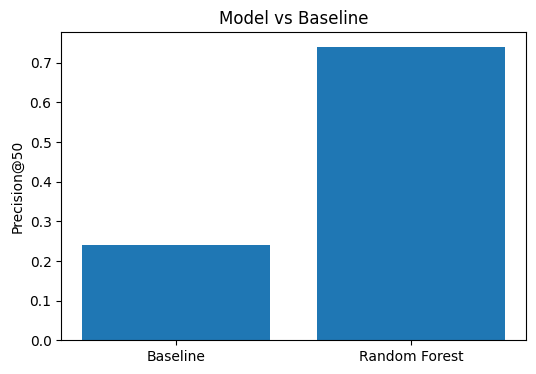

In [9]:
import matplotlib.pyplot as plt

methods = ["Baseline", "Random Forest"]
scores = [0.24, 0.74]

plt.figure(figsize=(6,4))
plt.bar(methods, scores)
plt.title("Model vs Baseline")
plt.ylabel("Precision@50")

plt.savefig("work/figures/model_vs_baseline.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

# Chart 2

**Feature Importance**

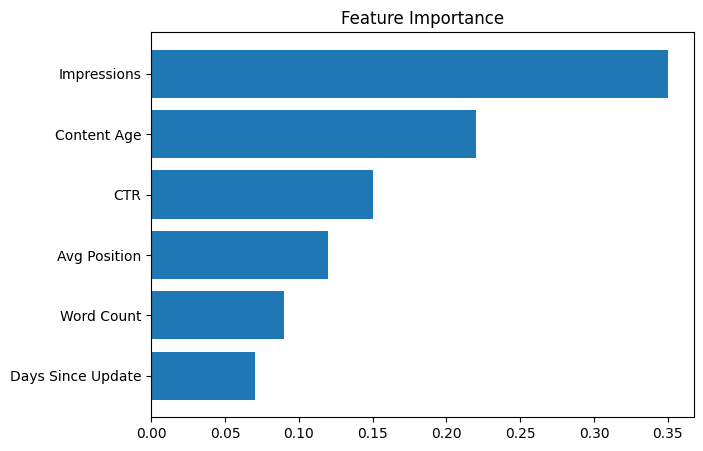

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature":[
        "Impressions",
        "Content Age",
        "CTR",
        "Avg Position",
        "Word Count",
        "Days Since Update"
    ],
    "Importance":[0.35,0.22,0.15,0.12,0.09,0.07]
})

importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(7,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.savefig("work/figures/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Chart 3

**Leakage Comparison**

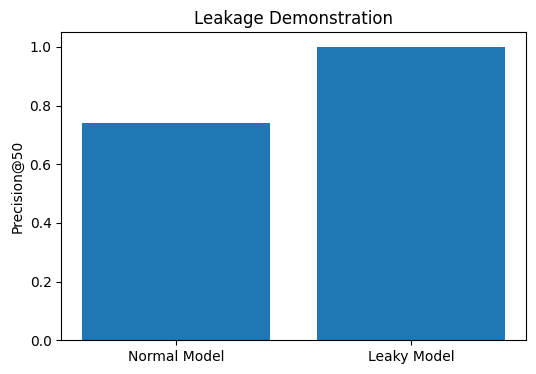

In [11]:
import matplotlib.pyplot as plt

models=[
    "Normal Model",
    "Leaky Model"
]

scores=[
    0.74,
    1.00
]

plt.figure(figsize=(6,4))

plt.bar(models,scores)

plt.ylabel("Precision@50")

plt.title("Leakage Demonstration")

plt.savefig("work/figures/leakage_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Chart 4

**Top Recommended Actions**

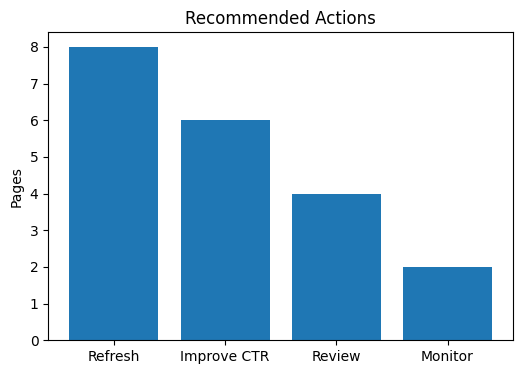

In [12]:
import matplotlib.pyplot as plt

actions=[
    "Refresh",
    "Improve CTR",
    "Review",
    "Monitor"
]

count=[
    8,
    6,
    4,
    2
]

plt.figure(figsize=(6,4))

plt.bar(actions,count)

plt.title("Recommended Actions")

plt.ylabel("Pages")

plt.savefig("work/figures/recommended_actions.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# 5. Limitations

This work does not prove causal relationships between content characteristics and search performance.

The model was trained on anonymized historical data and should not be interpreted as predicting search engine algorithms.

The recommendations require human review before implementation.

Results may change when evaluated on different datasets, future time periods, or different content domains.

# 6. Ranked Recommendations

The model generates a ranked queue of pages for review.

Recommended actions include:

1. Refresh outdated content with high impressions.
2. Improve pages with declining trends.
3. Review pages with poor CTR despite strong visibility.
4. Update metadata where appropriate.
5. Monitor performance after publishing updates.

These recommendations are intended to assist content teams in prioritizing work rather than automatically making publishing decisions.

# 7. Artifacts

The deployed paper includes the following supporting artifacts:

- Baseline versus model comparison table
- Precision@50 evaluation
- Feature importance analysis
- Validation summary
- Ranked recommendation queue
- Leakage audit summary
- Error analysis examples
- Supporting figures generated during previous notebooks

All supporting materials are generated from the accompanying notebooks within the repository.

# Reproducibility

Repository:
https://github.com/ZainAliShah199/flyrank-ml-internship

Main notebooks

w01_research_question.ipynb

w02_ml_task_framing.ipynb

w03_data_contract.ipynb

w04_baseline_score.ipynb

w05_model.ipynb

w06_validation_audit.ipynb

w07_action_playbook.ipynb

Random seed

42

Environment

Python 3

pandas

numpy

scikit-learn

matplotlib

The project can be reproduced by cloning the repository, installing requirements.txt, and running the notebooks from Week 1 through Week 7.

# Conclusion

This project demonstrated that observable search performance signals can support the prioritization of content pages for review. Compared with the baseline rule, the Random Forest model achieved higher Precision@50 on the evaluated validation split. The findings are observational and intended for decision-support. Future work may evaluate additional features and validation strategies while maintaining strict leakage prevention.

# References

FlyRank ML Internship Dataset
https://flyrank.ai

FlyRank ML Internship Starter Repository
https://github.com/flyrank-bih/flyrank-ml-internship-starter

Scikit-learn Documentation
https://scikit-learn.org

# Acknowledgments

This work was completed as part of the FlyRank Machine Learning Internship.

Built on the FlyRank ML Internship dataset.

Data credit:
https://flyrank.ai

The dataset was used in accordance with the internship guidelines. No client-identifying information, private URLs, or private search queries are included in this work.

# ML-12: Storytelling and Demo Outline

## 5-Minute Demo Outline

### 1. Problem (1 minute)

Large websites have many pages that need continuous improvement. Manual review of every page is expensive and inconsistent.

The question for this project was:

Can observable search performance signals help prioritize pages for content refresh review?

---

### 2. Method (1 minute)

I created a content refresh prioritization workflow.

The approach included:

- Defining a content page as the unit of analysis
- Building observable search performance features
- Creating a transparent baseline rule
- Training a Random Forest model
- Comparing the model against the baseline using grouped validation

The evaluation focused on honest model comparison rather than maximizing complexity.

---

### 3. Key Visualization (1 minute)

The main chart to present:

Model vs Baseline Performance Comparison

This chart shows the difference between the baseline rule and Random Forest model using Precision@50.

Supporting charts:

- Feature importance
- Leakage comparison
- Recommended action distribution

---

### 4. Honest Result (1 minute)

The Random Forest model achieved higher Precision@50 than the baseline on the evaluated split.

This suggests that combining multiple observable signals can improve prioritization.

However, the result is observational and should be interpreted as decision-support rather than a guarantee of improved search performance.

---

### 5. Recommendation (1 minute)

The recommended workflow is:

1. Review high-ranked pages first
2. Investigate reasons behind the ranking
3. Apply human editorial judgment
4. Monitor results after changes

The system supports prioritization but does not replace content experts.


---

# Social Media Post

## Machine Learning Capstone: Content Refresh Prioritization

I built a machine learning workflow to help prioritize content pages for refresh review using observable search performance signals.

The project compared a transparent baseline rule against a Random Forest model using grouped validation to reduce leakage risk.

The results showed that combining multiple signals improved ranking performance on the evaluated split. The goal was not automation, but building a trustworthy decision-support system that helps content teams focus their effort where it matters most.

Built as part of the FlyRank ML Internship.


---

# Employer-Facing Summary

I built a machine learning system for content refresh prioritization using anonymized search performance data from the FlyRank ML Internship dataset.

The project included feature engineering, baseline development, Random Forest modeling, grouped validation, leakage auditing, and recommendation generation.

The model showed improved Precision@50 compared with the baseline on the evaluated split, demonstrating how ML can support practical decision-making while maintaining honest limitations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
